### Demand forecast experiments
* run on the real 2015 to 2017 bookings of the two hotels, kept as the reference of what the real data supports
* weekly stayed arrivals per hotel, rolling origin backtest with an eight week horizon
* the series holds about two years, so yearly seasonality is handled with Fourier terms, last year's profile and the rooms already on the books rather than seasonal differencing
* autocorrelation, stationarity and residual diagnostics before the backtest
* statistical models, a gradient boosting model on lags and calendar, models on the rooms on the books at the origin, and stacks of them
* learning curves per origin, in sample error of the fitted model against its forecast error on the horizon
* results table printed at the end

In [1]:
import os
import json
import datetime
import warnings
import numpy as np
import pandas as pd
import lightgbm as lgb
import matplotlib.pyplot as plt
from statsmodels.tsa.seasonal import STL
from statsmodels.tsa.arima.model import ARIMA
from statsmodels.tsa.stattools import adfuller, acf
from statsmodels.tsa.statespace.sarimax import SARIMAX
from statsmodels.stats.diagnostic import acorr_ljungbox
from statsmodels.tsa.forecasting.theta import ThetaModel
from statsmodels.tsa.holtwinters import ExponentialSmoothing
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
warnings.filterwarnings("ignore")

ROOT_DIR = os.path.abspath(os.path.join(os.getcwd(), ".."))
PARQUET_PATH = os.path.join(ROOT_DIR, "data", "parquet", "bookings.parquet")
HOLIDAYS_PATH = os.path.join(ROOT_DIR, "data", "parquet", "holidays.parquet")
MODELS_DIR = os.path.join(ROOT_DIR, "data", "models")
hotels = ["City Hotel", "Resort Hotel"]
horizon = 8
origins = 20

In [2]:
# weekly stayed arrivals per hotel and the rooms on the books for each target week as seen at an origin
def load_bookings(path):
    frame = pd.read_parquet(path)
    for col in ["arrival_date", "booking_date", "leave_books_date"]:
        frame[col] = pd.to_datetime(frame[col])
    frame["week"] = frame["arrival_date"].dt.to_period("W-SUN").dt.end_time.dt.normalize()
    return frame

In [3]:
# weekly stayed arrivals series for one hotel, complete weeks only
def weekly_series(frame, hotel):
    stayed = frame[(frame["hotel"] == hotel) & (frame["is_canceled"] == 0)]
    series = stayed.groupby("week").size().astype(float)
    series = series.asfreq("W-SUN").fillna(0)
    return series.iloc[:-1]

In [4]:
# arrivals already on the books at an origin for each target week, bookings not yet cancelled at the origin
def on_books_at(frame, hotel, origin, weeks):
    part = frame[(frame["hotel"] == hotel) & (frame["booking_date"] <= origin) & (frame["leave_books_date"] > origin) & frame["week"].isin(weeks)]
    return part.groupby("week").size().reindex(weeks).fillna(0).values

In [5]:
# holiday counts in portugal and the main markets per week
def weekly_holidays(path, weeks):
    hol = pd.read_parquet(path)
    hol["date"] = pd.to_datetime(hol["date"])
    hol = hol[hol["kind"] == "public"]
    hol["week"] = hol["date"].dt.to_period("W-SUN").dt.end_time.dt.normalize()
    counts = hol.groupby("week").size()
    return counts.reindex(weeks).fillna(0).values

In [6]:
# seasonal naive, the value 52 weeks earlier
def f_seasonal_naive(history, steps, extra):
    v = history.values
    return np.array([v[len(v) - 52 + i] if len(v) >= 52 else v[-1] for i in range(steps)])

In [7]:
# holt winters with yearly seasonality when two cycles exist, damped trend only otherwise
def f_ets(history, steps, extra):
    v = history.values
    if len(v) < 104:
        return np.clip(ExponentialSmoothing(v, trend="add", damped_trend=True).fit().forecast(steps), 0, None)
    return np.clip(ExponentialSmoothing(v, trend="add", seasonal="add", seasonal_periods=52, damped_trend=True).fit().forecast(steps), 0, None)

In [8]:
# regression on fourier terms of the yearly cycle with arima errors, estimable with one cycle of history
def fourier_terms(index, k=3):
    t = np.arange(len(index))
    woy = pd.Index(index).isocalendar().week.astype(float).values
    cols = {}
    for j in range(1, k + 1):
        cols["s" + str(j)] = np.sin(2 * np.pi * j * woy / 52)
        cols["c" + str(j)] = np.cos(2 * np.pi * j * woy / 52)
    cols["t"] = t
    return pd.DataFrame(cols, index=index)


def f_sarima(history, steps, extra):
    v = history.values
    if len(v) < 60:
        return f_ets(history, steps, extra)
    future_index = pd.date_range(history.index[-1] + pd.Timedelta(weeks=1), periods=steps, freq="W-SUN")
    x_all = fourier_terms(history.index.append(future_index))
    x_hist = x_all.iloc[:len(v)]
    x_fut = x_all.iloc[len(v):]
    model = SARIMAX(v, exog=x_hist.values, order=(1, 0, 1), trend="c", enforce_stationarity=False, enforce_invertibility=False).fit(disp=False, maxiter=300)
    return np.clip(model.forecast(steps, exog=x_fut.values), 0, None)

In [9]:
# last year's same weeks scaled by the growth of the last eight weeks against the same weeks a year earlier
def f_stl_arima(history, steps, extra):
    v = history.values
    if len(v) < 60:
        return f_ets(history, steps, extra)
    recent = v[-8:].sum()
    same_ly = v[-60:-52].sum() if len(v) >= 60 else recent
    growth = np.clip(recent / max(same_ly, 1.0), 0.5, 2.0)
    profile = np.array([v[len(v) - 52 + i] if len(v) >= 52 + i + 1 or len(v) - 52 + i < len(v) else v[-1] for i in range(steps)])
    return np.clip(profile * growth, 0, None)

In [10]:
# theta model on the level with the yearly profile removed by last year's ratio, works without two full cycles
def f_theta(history, steps, extra):
    v = history.values
    if len(v) < 60:
        return f_ets(history, steps, extra)
    model = ThetaModel(v, period=1, deseasonalize=False).fit()
    base = np.asarray(model.forecast(steps))
    profile = np.array([v[len(v) - 52 + i] for i in range(steps)])
    level = v[-8:].mean()
    return np.clip(base * profile / max(level, 1.0), 0, None)

In [11]:
# pickup model, arrivals on the books at the origin scaled by last year's pickup ratio for the same weeks ahead
def f_pickup(history, steps, extra):
    otb = extra["otb"]
    ratios = extra["ratios"]
    return np.clip(otb * ratios[:steps], 0, None)

In [12]:
# in sample fitted values of the damped exponential smoothing model
def fitted_ets(history):
    v = history.values
    if len(v) < 104:
        return np.clip(ExponentialSmoothing(v, trend="add", damped_trend=True).fit().fittedvalues, 0, None)
    return np.clip(ExponentialSmoothing(v, trend="add", seasonal="add", seasonal_periods=52, damped_trend=True).fit().fittedvalues, 0, None)

In [13]:
# in sample fitted values of the fourier regression with arima errors
def fitted_sarima(history):
    v = history.values
    if len(v) < 60:
        return fitted_ets(history)
    model = SARIMAX(v, exog=fourier_terms(history.index).values, order=(1, 0, 1), trend="c", enforce_stationarity=False, enforce_invertibility=False).fit(disp=False, maxiter=300)
    return np.clip(model.fittedvalues, 0, None)

In [14]:
# train against test error per origin, in sample mape of the fitted model against the mape of its forecast on the horizon
def learning_curve(series, hotel, origins, steps):
    methods = {"ets": (f_ets, fitted_ets), "fourier_arima": (f_sarima, fitted_sarima)}
    rows = []
    last_origin = len(series) - steps
    for origin_idx in range(last_origin - origins + 1, last_origin + 1):
        history = series.iloc[:origin_idx]
        actual = series.iloc[origin_idx:origin_idx + steps].values
        for name, (forecast, fitted) in methods.items():
            train_mape = errors(history.values[10:], fitted(history)[10:], history.values[10:])[0]
            test_mape = errors(actual, forecast(history, steps, None), actual)[0]
            rows.append({"hotel": hotel, "origin": str(history.index[-1].date()), "method": name, "train_mape": round(train_mape, 4), "test_mape": round(test_mape, 4)})
    return pd.DataFrame(rows)

In [15]:
# learning curves per method, in sample against forecast mape by origin
def plot_learning_curve(curve, hotel, steps):
    part = curve[curve["hotel"] == hotel]
    methods = part["method"].unique()
    fig, axes = plt.subplots(1, len(methods), figsize=(6 * len(methods), 3.5), sharey=True)
    for ax, name in zip(np.atleast_1d(axes), methods):
        m = part[part["method"] == name]
        ax.plot(pd.to_datetime(m["origin"]), m["train_mape"], marker="o", color="blue", label="train, in sample")
        ax.plot(pd.to_datetime(m["origin"]), m["test_mape"], marker="o", color="red", label="test, " + str(steps) + " weeks ahead")
        ax.set_title(name)
        ax.set_xlabel("origin")
        ax.legend()
    np.atleast_1d(axes)[0].set_ylabel("mape")
    fig.suptitle("Learning curves, " + hotel)
    plt.tight_layout()
    plt.show()

In [16]:
# lag and calendar features for the gradient boosting model
def lag_features(series):
    out = pd.DataFrame({"y": series.values}, index=series.index)
    for lag in [1, 2, 3, 4, 8, 12, 52]:
        out["lag_" + str(lag)] = out["y"].shift(lag)
    out["roll_4"] = out["y"].shift(1).rolling(4).mean()
    out["roll_12"] = out["y"].shift(1).rolling(12).mean()
    out["woy"] = out.index.isocalendar().week.astype(int).values
    out["sin1"] = np.sin(2 * np.pi * out["woy"] / 52)
    out["cos1"] = np.cos(2 * np.pi * out["woy"] / 52)
    out["sin2"] = np.sin(4 * np.pi * out["woy"] / 52)
    out["cos2"] = np.cos(4 * np.pi * out["woy"] / 52)
    return out

In [17]:
# direct gradient boosting, one model per horizon step, on lags at the origin plus calendar of the target week
def f_gbm(history, steps, extra):
    series = history
    feats = lag_features(series)
    params = {"objective": "regression", "learning_rate": 0.05, "num_leaves": 7, "min_data_in_leaf": 8, "lambda_l2": 5.0, "verbose": -1, "num_threads": 2, "seed": 7}
    preds = []
    for h in range(1, steps + 1):
        target = feats["y"].shift(-h)
        train = feats.drop(columns="y").assign(target_woy=feats["woy"].shift(-h))
        train = train.assign(y=target).dropna()
        if len(train) < 40:
            preds.append(float(series.values[-52 + h - 1]) if len(series) >= 52 else float(series.values[-1]))
            continue
        model = lgb.train(params, lgb.Dataset(train.drop(columns="y"), label=train["y"]), num_boost_round=200)
        last = feats.drop(columns="y").iloc[[-1]].copy()
        last["target_woy"] = ((series.index[-1] + pd.Timedelta(weeks=h)).isocalendar()[1])
        preds.append(max(float(model.predict(last)[0]), 0.0))
    return np.array(preds)

In [18]:
# stack, gradient boosting on the forecasts of the other models plus on the books, trained on earlier origins
def f_stack(history, steps, extra):
    table = extra["stack_train"]
    if table is None or len(table) < 60:
        return np.mean([extra["members"][m] for m in extra["members"]], axis=0)
    params = {"objective": "regression", "learning_rate": 0.05, "num_leaves": 5, "min_data_in_leaf": 10, "lambda_l2": 10.0, "verbose": -1, "num_threads": 2, "seed": 7}
    model = lgb.train(params, lgb.Dataset(table.drop(columns="y"), label=table["y"]), num_boost_round=150)
    row = pd.DataFrame({m: extra["members"][m] for m in extra["members"]})
    row["otb"] = extra["otb"][:steps]
    row["h"] = np.arange(1, steps + 1)
    return np.clip(model.predict(row[table.drop(columns="y").columns]), 0, None)

In [19]:
# mean absolute percentage error and mean absolute scaled error against the seasonal naive
def errors(actual, forecast, naive):
    actual = np.asarray(actual, dtype=float)
    mask = actual > 0
    mape = float(np.mean(np.abs(actual[mask] - forecast[mask]) / actual[mask]))
    mase = float(np.mean(np.abs(actual - forecast)) / max(np.mean(np.abs(actual - naive)), 1e-9))
    return mape, mase

In [20]:
# last year's pickup ratios for each number of weeks ahead, final arrivals divided by arrivals on the books
def pickup_ratios(frame, hotel, origin, steps):
    ratios = []
    for h in range(1, steps + 1):
        weeks_ly = [origin - pd.Timedelta(weeks=52) + pd.Timedelta(weeks=h)]
        target = frame[(frame["hotel"] == hotel) & frame["week"].isin(weeks_ly)]
        final = float((target["is_canceled"] == 0).sum())
        otb = float(((target["booking_date"] <= origin - pd.Timedelta(weeks=52)) & (target["leave_books_date"] > origin - pd.Timedelta(weeks=52))).sum())
        ratios.append(final / otb if otb >= 5 else 1.0)
    return np.clip(np.array(ratios), 0.5, 6.0)

In [21]:
# rolling origin backtest of every method for one hotel, the stack learns from the earlier origins
def backtest(frame, hotel, hol_counts, origins, steps):
    series = weekly_series(frame, hotel)
    base_methods = {"seasonal_naive": f_seasonal_naive, "ets": f_ets, "fourier_arima": f_sarima, "profile_growth": f_stl_arima, "theta_profile": f_theta, "gbm": f_gbm, "pickup": f_pickup}
    rows = []
    stack_rows = []
    last_origin = len(series) - steps
    for origin_idx in range(last_origin - origins + 1, last_origin + 1):
        history = series.iloc[:origin_idx]
        origin = history.index[-1]
        target_weeks = series.index[origin_idx:origin_idx + steps]
        actual = series.iloc[origin_idx:origin_idx + steps].values
        otb = on_books_at(frame, hotel, origin, target_weeks)
        extra = {"otb": otb, "ratios": pickup_ratios(frame, hotel, origin, steps)}
        members = {}
        for name, fn in base_methods.items():
            members[name] = fn(history, steps, extra)
        naive = members["seasonal_naive"]
        members["mean_ets_fourier_pickup"] = np.mean([members["ets"], members["fourier_arima"], members["pickup"]], axis=0)
        members["mean_all"] = np.mean([members[m] for m in ["ets", "fourier_arima", "profile_growth", "theta_profile", "gbm", "pickup"]], axis=0)
        stack_train = pd.DataFrame(stack_rows) if stack_rows else None
        extra["members"] = {m: members[m] for m in ["ets", "fourier_arima", "profile_growth", "gbm", "pickup"]}
        extra["stack_train"] = stack_train
        members["stack"] = f_stack(history, steps, extra)
        for h in range(steps):
            row = {m: members[m][h] for m in ["ets", "fourier_arima", "profile_growth", "gbm", "pickup"]}
            row["otb"] = otb[h]
            row["h"] = h + 1
            row["y"] = actual[h]
            stack_rows.append(row)
        for name, fc in members.items():
            mape, mase = errors(actual, fc, naive)
            rows.append({"hotel": hotel, "origin": str(origin.date()), "method": name, "mape": mape, "mase": mase})
    return pd.DataFrame(rows), series

In [22]:
# plot the last origin
def plot_last(frame, hotel, series, steps, methods):
    origin_idx = len(series) - steps
    history = series.iloc[:origin_idx]
    origin = history.index[-1]
    target_weeks = series.index[origin_idx:]
    extra = {"otb": on_books_at(frame, hotel, origin, target_weeks), "ratios": pickup_ratios(frame, hotel, origin, steps)}
    plt.figure(figsize=(10, 4))
    plt.plot(series.index[-60:], series.values[-60:], color="gray", label="actual")
    colors = ["orange", "green", "blue", "red", "purple"]
    for (name, fn), color in zip(methods.items(), colors):
        plt.plot(target_weeks, fn(history, steps, extra), color=color, label=name)
    plt.title("Weekly arrivals forecast, " + hotel)
    plt.ylabel("arrivals")
    plt.legend()
    plt.show()

In [23]:
# autocorrelation of the weekly series and of its yearly difference
def plot_autocorrelation(series, hotel):
    fig, axes = plt.subplots(2, 2, figsize=(11, 6))
    plot_acf(series.values, lags=60, ax=axes[0, 0], title="ACF, weekly arrivals, " + hotel)
    plot_pacf(series.values, lags=40, ax=axes[0, 1], method="ywm", title="PACF, weekly arrivals")
    diff = series.diff(52).dropna()
    plot_acf(diff.values, lags=30, ax=axes[1, 0], title="ACF, yearly difference")
    plot_pacf(diff.values, lags=20, ax=axes[1, 1], method="ywm", title="PACF, yearly difference")
    plt.tight_layout()
    plt.show()

In [24]:
# augmented dickey fuller test on the level and on the yearly difference
def stationarity(series):
    level = adfuller(series.values, autolag="AIC")
    diff = adfuller(series.diff(52).dropna().values, autolag="AIC")
    return {"adf_level": round(float(level[0]), 3), "p_level": round(float(level[1]), 4), "adf_yearly_diff": round(float(diff[0]), 3), "p_yearly_diff": round(float(diff[1]), 4)}

In [25]:
# in sample residual autocorrelation of two models, ljung box at lags 8 and 26
def residual_diagnostics(series):
    v = series.values
    idx = series.index
    x = fourier_terms(idx)
    fa = SARIMAX(v, exog=x.values, order=(1, 0, 1), trend="c", enforce_stationarity=False, enforce_invertibility=False).fit(disp=False, maxiter=300)
    holt = ExponentialSmoothing(v, trend="add", damped_trend=True).fit()
    out = {}
    for name, resid in [("fourier_arima", fa.resid[10:]), ("holt_damped", holt.resid[10:])]:
        lb = acorr_ljungbox(resid, lags=[8, 26], return_df=True)
        out[name] = {"lb_p_lag8": round(float(lb["lb_pvalue"].iloc[0]), 4), "lb_p_lag26": round(float(lb["lb_pvalue"].iloc[1]), 4), "resid_acf1": round(float(acf(resid, nlags=1)[1]), 3), "resid_acf52": round(float(acf(resid, nlags=52)[52]), 3) if len(resid) > 52 else None}
    fig, axes = plt.subplots(1, 2, figsize=(11, 3))
    plot_acf(fa.resid[10:], lags=40, ax=axes[0], title="ACF of fourier arima residuals")
    plot_acf(holt.resid[10:], lags=40, ax=axes[1], title="ACF of damped holt residuals")
    plt.tight_layout()
    plt.show()
    return out

City Hotel, weeks 113, from 2015-07-05 to 2017-08-27


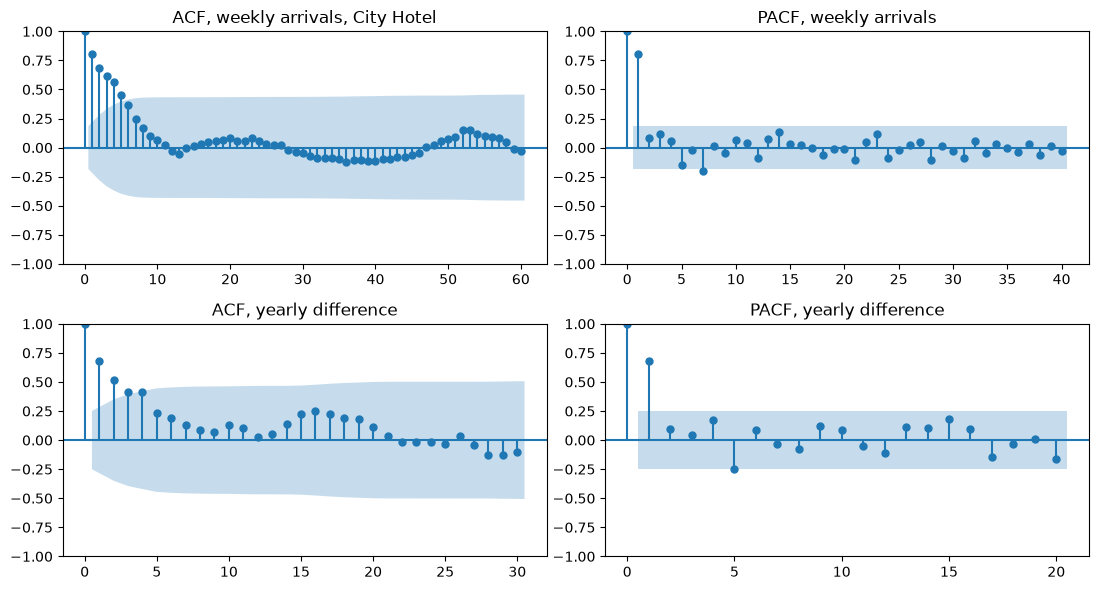

stationarity {"adf_level": -2.914, "p_level": 0.0438, "adf_yearly_diff": -3.15, "p_yearly_diff": 0.023}


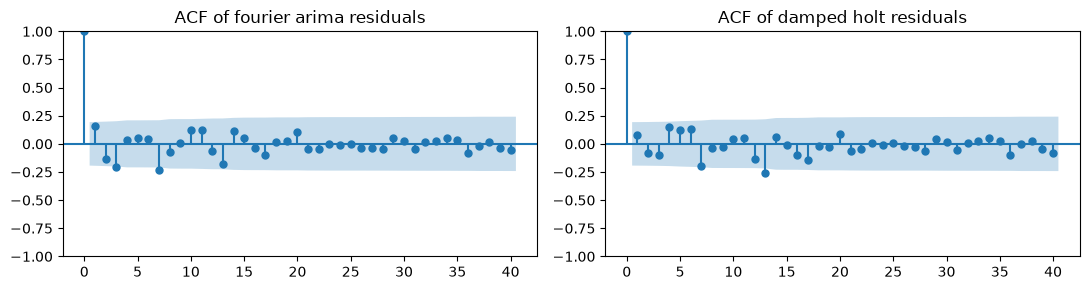

residual diagnostics {"fourier_arima": {"lb_p_lag8": 0.0358, "lb_p_lag26": 0.2815, "resid_acf1": 0.156, "resid_acf52": 0.107}, "holt_damped": {"lb_p_lag8": 0.1132, "lb_p_lag26": 0.2582, "resid_acf1": 0.077, "resid_acf52": 0.195}}
Resort Hotel, weeks 113, from 2015-07-05 to 2017-08-27


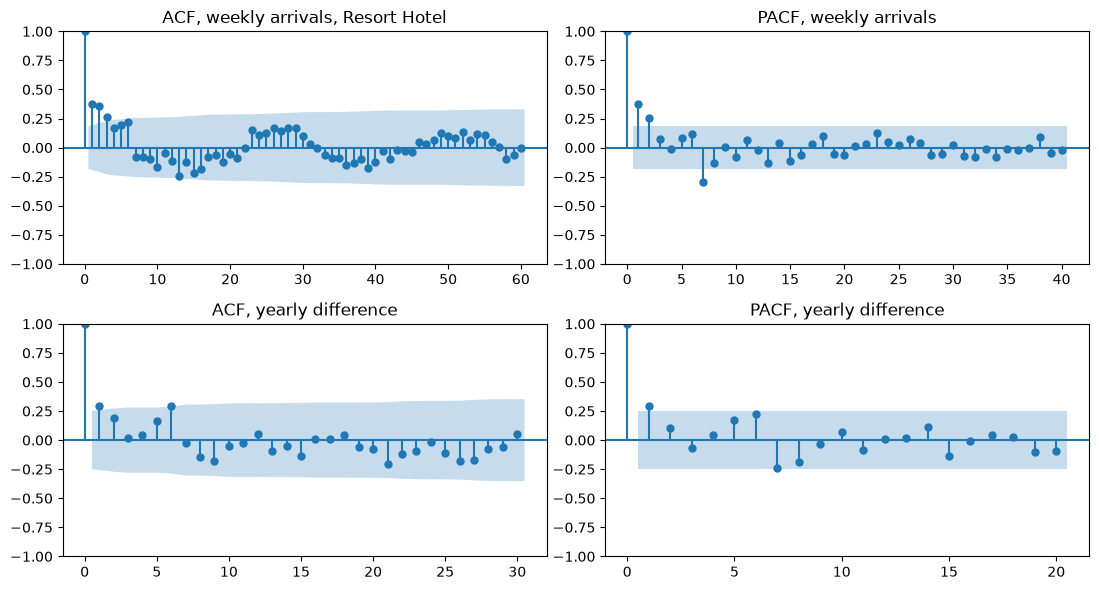

stationarity {"adf_level": -3.36, "p_level": 0.0124, "adf_yearly_diff": -5.602, "p_yearly_diff": 0.0}


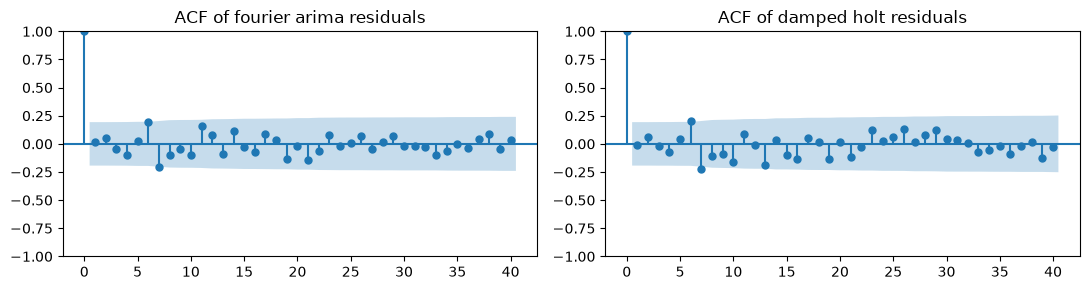

residual diagnostics {"fourier_arima": {"lb_p_lag8": 0.1738, "lb_p_lag26": 0.3367, "resid_acf1": 0.019, "resid_acf52": -0.025}, "holt_damped": {"lb_p_lag8": 0.1156, "lb_p_lag26": 0.1075, "resid_acf1": -0.01, "resid_acf52": 0.062}}


In [26]:
frame = load_bookings(PARQUET_PATH)
diagnostics = {}
for hotel in hotels:
    series = weekly_series(frame, hotel)
    print(hotel + ", weeks " + str(len(series)) + ", from " + str(series.index[0].date()) + " to " + str(series.index[-1].date()))
    plot_autocorrelation(series, hotel)
    st = stationarity(series)
    print("stationarity " + json.dumps(st))
    rd = residual_diagnostics(series)
    print("residual diagnostics " + json.dumps(rd))
    diagnostics[hotel] = {"stationarity": st, "residuals": rd, "weeks": int(len(series))}

In [27]:
all_results = []
series_by_hotel = {}
for hotel in hotels:
    res, series = backtest(frame, hotel, None, origins, horizon)
    all_results.append(res)
    series_by_hotel[hotel] = series
results = pd.concat(all_results)
summary = results.groupby(["hotel", "method"])[["mape", "mase"]].mean().round(4)
pd.set_option("display.width", 200)
print("mean over " + str(origins) + " origins, " + str(horizon) + " weeks ahead")
print(summary.sort_values(["hotel", "mape"]).to_string())

mean over 20 origins, 8 weeks ahead
                                        mape    mase
hotel        method                                 
City Hotel   stack                    0.0510  0.5219
             mean_ets_fourier_pickup  0.0599  0.5917
             mean_all                 0.0697  0.7042
             fourier_arima            0.0813  0.8156
             ets                      0.0824  0.8414
             gbm                      0.0891  0.9176
             pickup                   0.0974  0.9913
             seasonal_naive           0.0977  1.0000
             profile_growth           0.1138  1.1612
             theta_profile            0.1263  1.3250
Resort Hotel pickup                   0.1066  0.5723
             mean_ets_fourier_pickup  0.1104  0.6042
             stack                    0.1141  0.5812
             mean_all                 0.1309  0.7168
             ets                      0.1330  0.7887
             gbm                      0.1595  0.9119
          

In [28]:
by_h = results.copy()
print("mape by method, both hotels")
print(results.groupby("method")["mape"].mean().sort_values().round(4).to_string())

mape by method, both hotels
method
stack                      0.0825
mean_ets_fourier_pickup    0.0851
mean_all                   0.1003
pickup                     0.1020
ets                        0.1077
fourier_arima              0.1213
gbm                        0.1243
seasonal_naive             0.1358
theta_profile              0.1546
profile_growth             0.1703


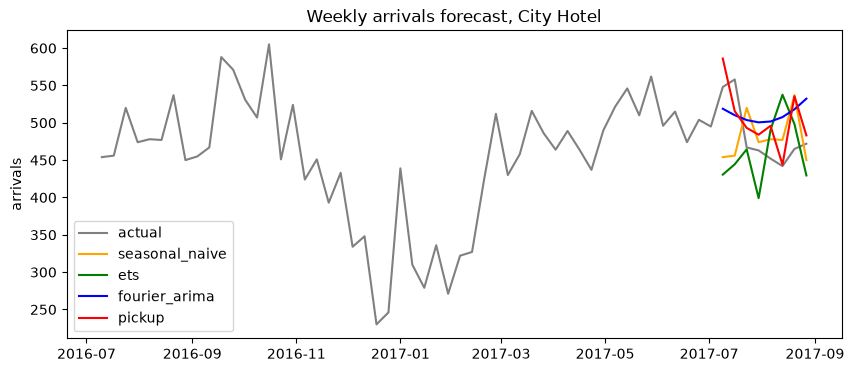

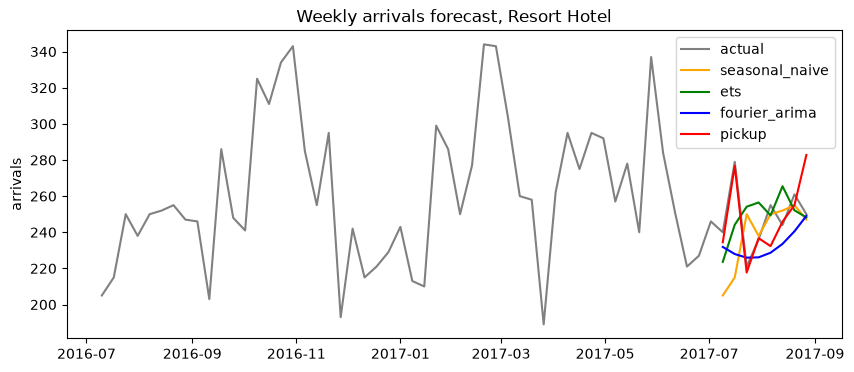

In [29]:
for hotel in hotels:
    plot_last(frame, hotel, series_by_hotel[hotel], horizon, {"seasonal_naive": f_seasonal_naive, "ets": f_ets, "fourier_arima": f_sarima, "pickup": f_pickup})

mean mape over 20 origins, in sample against 8 weeks ahead
                            train_mape  test_mape
hotel        method                              
City Hotel   ets                0.1588     0.0824
             fourier_arima      0.1279     0.0813
Resort Hotel ets                0.1553     0.1330
             fourier_arima      0.1422     0.1613


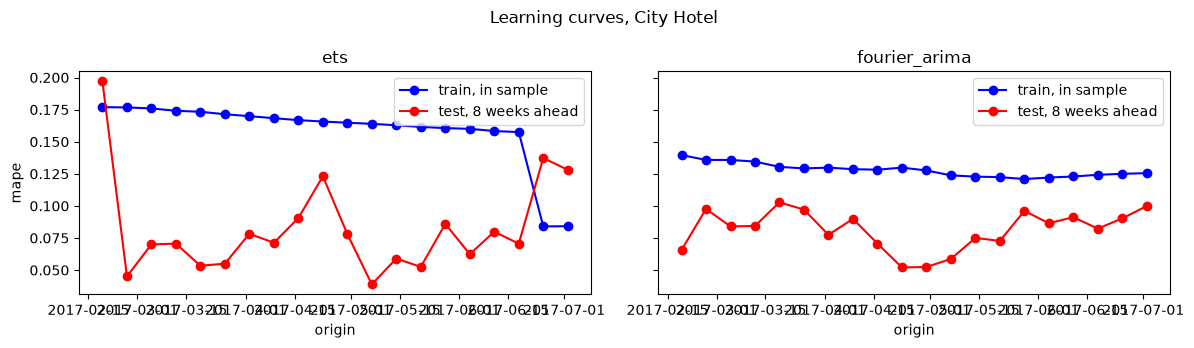

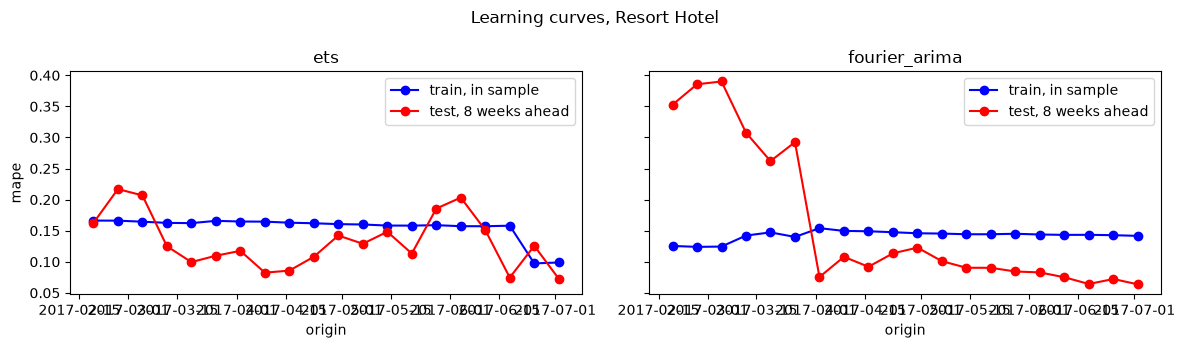

In [30]:
curve = pd.concat([learning_curve(series_by_hotel[hotel], hotel, origins, horizon) for hotel in hotels], ignore_index=True)
print("mean mape over " + str(origins) + " origins, in sample against " + str(horizon) + " weeks ahead")
print(curve.groupby(["hotel", "method"])[["train_mape", "test_mape"]].mean().round(4).to_string())
for hotel in hotels:
    plot_learning_curve(curve, hotel, horizon)

In [31]:
out = {"summary": summary.reset_index().to_dict("records"), "origins": origins, "diagnostics": diagnostics, "horizon": horizon, "learning_curve": curve.to_dict("records"), "generated_at": datetime.datetime.now(datetime.timezone.utc).isoformat()}
with open(os.path.join(MODELS_DIR, "experiments_forecast.json"), "w") as f:
    json.dump(out, f, indent=1)
print("saved " + os.path.join(MODELS_DIR, "experiments_forecast.json"))

saved /srv/data/models/experiments_forecast.json
